# 01 - Data Understanding

This notebook covers initial dataset inspection for the Kaggle Credit Card Fraud Detection dataset (`data/raw/creditcard.csv`).

Goals:
- confirm schema and target column
- inspect missing values and duplicates
- inspect class imbalance in `Class`

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

DATA_PATH = Path("../data/raw/creditcard.csv")
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print("Columns:", df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [3]:
missing_values = df.isna().sum().sort_values(ascending=False)
duplicates = int(df.duplicated().sum())

print("Total missing values:", int(missing_values.sum()))
print("Duplicate rows:", duplicates)
missing_values.head(10)

Total missing values: 0
Duplicate rows: 1081


Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio: 0.001727
Imbalance ratio (non-fraud:fraud): 577.88:1


C:\Users\Amrish\AppData\Local\Temp\ipykernel_3412\1218395102.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='Set2')


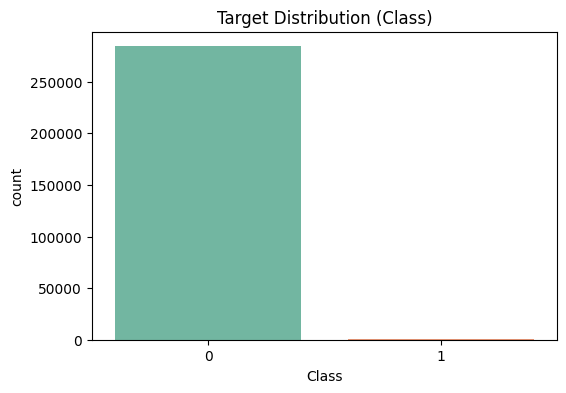

: 

In [ ]:
class_dist = df['Class'].value_counts().sort_index()
fraud_ratio = class_dist[1] / class_dist.sum()
imbalance_ratio = class_dist[0] / class_dist[1]

print("Class distribution:")
print(class_dist)
print(f"Fraud ratio: {fraud_ratio:.6f}")
print(f"Imbalance ratio (non-fraud:fraud): {imbalance_ratio:.2f}:1")

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class', palette='Set2')
plt.title('Target Distribution (Class)')
plt.show()

## Key Takeaway

The dataset is highly imbalanced. A naive classifier can produce high **accuracy** by predicting all samples as non-fraud. This motivates precision-recall focused evaluation in later notebooks.